# ML4: Binary Classification, Metrics & Model Implementation
Анализ алгоритмов классификации и методов оптимизации на данных [Don't Get Kicked!](https://www.kaggle.com/competitions/DontGetKicked/overview) (Kaggle).

В этой части рассматриваются:
- обучение стандартных классификаторов (LogisticRegression, GaussianNB, KNN) из библиотеки sklearn и их сопоставление с собственными реализациями (SGD-логистическая регрессия, NaiveBayes, KNN)
- реализация и расчет метрик Precision, Recall, F1, AUC PR
- расчет коэффициента Gini на разных выборках и проверка моделей на переобучение
--- 

## Подготовка данных и валидация

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import roc_auc_score

import metrics_utils
from calculation_metrics import calculate_metrics
from gini import custom_gini 
from logistic_regression import MyLogisticRegression
from naive_bayes import MyNaiveBayes
from knn import MyKNN

##### 1. Загрузка данных Don'tGetKicked.

In [3]:
train_df = pd.read_csv('data/training.csv')

In [4]:
train_df

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72978,73010,1,12/2/2009,ADESA,2001,8,MERCURY,SABLE,GS,4D SEDAN GS,...,4836.0,5937.0,NaN,NaN,18111,30212,GA,4200.0,0,993
72979,73011,0,12/2/2009,ADESA,2007,2,CHEVROLET,MALIBU 4C,LS,4D SEDAN LS,...,10151.0,11652.0,NaN,NaN,18881,30212,GA,6200.0,0,1038
72980,73012,0,12/2/2009,ADESA,2005,4,JEEP,GRAND CHEROKEE 2WD V,Lar,4D WAGON LAREDO,...,11831.0,14402.0,NaN,NaN,18111,30212,GA,8200.0,0,1893
72981,73013,0,12/2/2009,ADESA,2006,3,CHEVROLET,IMPALA,LS,4D SEDAN LS,...,10099.0,11228.0,NaN,NaN,18881,30212,GA,7000.0,0,1974


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  object 
 3   Auction                            72983 non-null  object 
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  object 
 7   Model                              72983 non-null  object 
 8   Trim                               70623 non-null  object 
 9   SubModel                           72975 non-null  object 
 10  Color                              72975 non-null  object 
 11  Transmission                       72974 non-null  obj

**Основная информация**
- **RefId** — Уникальный идентификатор записи.
- **IsBadBuy** — Целевая переменная (1 — плохая покупка, 0 — хорошая).
- **PurchDate** — Дата покупки автомобиля на аукционе.
- **Auction** — Тип аукциона, на котором продавался автомобиль (MANHEIM, ADESA и др.). Отражает условия продажи.
- **VehYear** — Год выпуска автомобиля.
- **VehicleAge** — Возраст автомобиля на момент продажи (в годах).

**Характеристики автомобиля**
- **Make** — Марка автомобиля (Toyota, Ford, BMW и т.д.).
- **Model** — Модель автомобиля.
- **Trim** — Комплектация автомобиля (LX, SE, Sport и т.д.).
- **SubModel** — Вариант модели (например, LE, EX-L).
- **Color** — Цвет кузова.
- **Transmission** — Тип коробки передач (AUTO, MANUAL).
- **WheelType / WheelTypeID** — Тип дисков (Alloy, Covers, Special) и его числовой идентификатор.
- **VehOdo** — Пробег автомобиля по одометру (в милях).
- **Size** — Размерный класс автомобиля (COMPACT, MEDIUM, SUV и т.д.).
- **Nationality** — Регион происхождения бренда (AMERICAN, ASIAN, OTHER).
- **TopThreeAmericanName** — Принадлежность бренда к «большой тройке» США (FORD, GM, CHRYSLER).

**Ценовые показатели (MMR — Manheim Market Report)**
- **MMRAcquisitionAuctionAveragePrice** — Средняя аукционная цена при покупке.
- **MMRAcquisitionAuctionCleanPrice** — Цена на аукционе для авто в хорошем («чистом») состоянии при покупке.
- **MMRAcquisitionRetailAveragePrice** — Средняя розничная цена при покупке.
- **MMRAquisitonRetailCleanPrice** — Розничная цена для «чистых» авто при покупке.
- **MMRCurrentAuctionAveragePrice** — Текущая средняя аукционная цена.
- **MMRCurrentAuctionCleanPrice** — Текущая цена аукциона для «чистых» авто.
- **MMRCurrentRetailAveragePrice** — Текущая средняя розничная цена.
- **MMRCurrentRetailCleanPrice** — Текущая розничная цена для «чистых» авто.

**Дополнительные параметры сделки**
- **PRIMEUNIT** — Флаг приоритетного лота (YES/NO).
- **AUCGUART** — Гарантия аукциона (GREEN — есть, RED — нет). Отражает техническое состояние.
- **BYRNO** — Уникальный номер покупателя (дилера).
- **VNZIP1 / VNST** — Почтовый индекс и штат регистрации автомобиля.
- **VehBCost** — Себестоимость автомобиля (затраты дилера на приобретение).
- **IsOnlineSale** — Флаг продажи через интернет (1 — онлайн, 0 — очно).
- **WarrantyCost** — Стоимость гарантийного обслуживания.

In [6]:
train_df.duplicated().sum()

np.int64(0)

In [7]:
train_df.isna().sum().sort_values(ascending=False)

PRIMEUNIT                            69564
AUCGUART                             69564
WheelType                             3174
WheelTypeID                           3169
Trim                                  2360
MMRCurrentAuctionAveragePrice          315
MMRCurrentRetailCleanPrice             315
MMRCurrentRetailAveragePrice           315
MMRCurrentAuctionCleanPrice            315
MMRAcquisitionAuctionAveragePrice       18
MMRAcquisitionAuctionCleanPrice         18
MMRAcquisitionRetailAveragePrice        18
MMRAcquisitonRetailCleanPrice           18
Transmission                             9
SubModel                                 8
Color                                    8
Nationality                              5
Size                                     5
TopThreeAmericanName                     5
BYRNO                                    0
VNZIP1                                   0
VNST                                     0
VehBCost                                 0
IsOnlineSal

Признаки `PRIMEUNIT` и `AUCGUART` содержат более 95% пропусков (69564 из 72983), не несут в себе никакой информативной ценности

Проверим взаимосвязь `WheelTypeID` и `WheelType`:

In [8]:
train_df.groupby(['WheelTypeID', 'WheelType']).size().reset_index(name='count')

,WheelTypeID,WheelType,count
0,1.0,Alloy,36050
1,2.0,Covers,33004
2,3.0,Special,755


`WheelTypeID` является числовым дубликатом текстового признака `WheelType`, `RefId` является уникальным идентификатором (индексом) и не несет предсказательной ценности

In [9]:
train_df.drop(columns=['PRIMEUNIT', 'AUCGUART', 'WheelTypeID', 'RefId'], inplace=True)

In [10]:
train_df.describe()

,IsBadBuy,VehYear,VehicleAge,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VehBCost,IsOnlineSale,WarrantyCost
count,72983.000000,72983.000000,72983.000000,72983.000000,72965.000000,72965.000000,72965.000000,72965.000000,72668.000000,72668.000000,72668.000000,72668.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000
mean,0.122988,2005.343052,4.176644,71499.995917,6128.909217,7373.636031,8497.034332,9850.928240,6132.081287,7390.681827,8775.723331,10145.385314,26345.842155,58043.059945,6730.934326,0.025280,1276.580985
std,0.328425,1.731252,1.712210,14578.913128,2461.992768,2722.491986,3156.285284,3385.789541,2434.567723,2686.248852,3090.702941,3310.254351,25717.351219,26151.640415,1767.846435,0.156975,598.846788
min,0.000000,2001.000000,0.000000,4825.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,835.000000,2764.000000,1.000000,0.000000,462.000000
25%,0.000000,2004.000000,3.000000,61837.000000,4273.000000,5406.000000,6280.000000,7493.000000,4275.000000,5414.000000,6536.000000,7784.000000,17212.000000,32124.000000,5435.000000,0.000000,837.000000
50%,0.000000,2005.000000,4.000000,73361.000000,6097.000000,7303.000000,8444.000000,9789.000000,6062.000000,7313.000000,8729.000000,10103.000000,19662.000000,73108.000000,6700.000000,0.000000,1155.000000
75%,0.000000,2007.000000,5.000000,82436.000000,7765.000000,9021.000000,10651.000000,12088.000000,7736.000000,9013.000000,10911.000000,12309.000000,22808.000000,80022.000000,7900.000000,0.000000,1623.000000
max,1.000000,2010.000000,9.000000,115717.000000,35722.000000,36859.000000,39080.000000,41482.000000,35722.000000,36859.000000,39080.000000,41062.000000,99761.000000,99224.000000,45469.000000,1.000000,7498.000000


In [11]:
train_df.select_dtypes(include=['object']).nunique().sort_values()

Auction                    3
Transmission               3
WheelType                  3
Nationality                4
TopThreeAmericanName       4
Size                      12
Color                     16
Make                      33
VNST                      37
Trim                     134
PurchDate                517
SubModel                 863
Model                   1063
dtype: int64

In [12]:
for col in train_df.select_dtypes(include='object'):
    bad = train_df[col].notna() & (train_df[col] != train_df[col].str.upper())
    if bad.any():
        print(col, train_df.loc[bad, col].unique(), sep = '\n')

Model
['SPORTAGE 2WD Multipl' 'MUSTANG V6 Unspecifi' 'LE SABRE Unspecified'
 'GALANT 4C Multiple E' 'ECHO Multiple Engine' 'MATRIX 2WD Multiple'
 'COROLLA Multiple Eng' 'RAV-4 2WD Multiple E' 'FOCUS Multiple Engin'
 'CAMRY 4C Multiple En' 'AVENGER V6 Unspecifi' 'CAMRY SOLARA 4C Mult'
 'GRAND AM V6 Unspecif' 'MATRIX 2WD Unspecifi' 'ALTIMA Multiple Engi'
 'XG 300 Unspecified' 'Pacifica' 'SANTA FE 4WD V6 Unsp']
Trim
['i' 'Bas' 'Spo' 'Lar' 'Adv' 'Tou' 'Lim' 's' 'Edd' 'Edg' 'Nor' 'Ren' 'Cla'
 'Spy' 'LXi' 'Exe' 'Pre' 'Cus' 'Si' 'Val' 'Car' 'eL' 'Spe' 'Pro' 'Cin'
 'Max' 'Ral' 'Sta' 'Lux' 'Her' 'Xsp' 'Kin' 'Hig' 'Plu' 'Ult' 'Ove' 'Den'
 'Sig' 'Dur' 'eC' 'Out' 'Maz' 'Ent' 'Har' 'Hyb']
Transmission
['Manual']
WheelType
['Alloy' 'Covers' 'Special']


In [13]:
train_df['Transmission'] = train_df['Transmission'].str.upper().fillna('UNKNOWN')
train_df['Transmission'].unique()

array(['AUTO', 'MANUAL', 'UNKNOWN'], dtype=object)

Проанализируем целевую переменную `IsBadBuy`:

In [14]:
train_df['IsBadBuy'].value_counts(normalize=True)

IsBadBuy
0    0.877012
1    0.122988
Name: proportion, dtype: float64

**87.7**% объектов относятся к классу 0 (хорошая покупка) и только **12.3**% к классу 1 (плохая покупка).
Такой дисбаланс означает, что модели могут склоняться к предсказанию большинства класса. Поэтому для оценки качества классификаторов необходимо использовать метрики, устойчивые к дисбалансу: ROC‑AUC, Gini, Precision, Recall, F1‑score и AUC‑PR.

При обучении моделей также потребуется учитывать дисбаланс классов `class_weight = 'balanced'`.

In [15]:
train_df['PurchDate'] = pd.to_datetime(train_df['PurchDate'])
train_df = train_df.sort_values('PurchDate').reset_index(drop=True)

In [16]:
train_df['PurchDate']

0       2009-01-05
1       2009-01-05
2       2009-01-05
3       2009-01-05
4       2009-01-05
           ...    
72978   2010-12-30
72979   2010-12-30
72980   2010-12-30
72981   2010-12-30
72982   2010-12-30
Name: PurchDate, Length: 72983, dtype: datetime64[ns]

##### 2. Разделение данных по времени: train < valid < test по полю PurchDate.

In [17]:
dates = train_df['PurchDate'].drop_duplicates()
bins = pd.qcut(dates, q=3, duplicates='drop')

train_date = bins.cat.categories[0].right
val_date = bins.cat.categories[1].right

train_df_split = train_df[train_df['PurchDate'] < train_date].copy()
val_df_split   = train_df[(train_df['PurchDate'] >= train_date) & (train_df['PurchDate'] < val_date)].copy()
test_df_split  = train_df[train_df['PurchDate'] >= val_date].copy()

In [18]:
display(train_df_split.shape)
display(val_df_split.shape)
display(test_df_split.shape)

(23059, 30)

(24104, 30)

(25820, 30)

In [19]:
train_df_split.head(5)

,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,0,2009-01-05,MANHEIM,2007,2,CHRYSLER,PACIFICA FWD 3.8L V6,Bas,4D SPORT,BLUE,...,8709.0,10331.0,9906.0,11657.0,3453,80022,CO,6770.0,0,1389
1,0,2009-01-05,MANHEIM,2005,4,FORD,FREESTAR FWD V6 3.9L,SES,4D PASSENGER 3.9L SES,SILVER,...,4908.0,5971.0,5801.0,6949.0,22916,80022,CO,6160.0,0,941
2,0,2009-01-05,MANHEIM,2004,5,DODGE,STRATUS 4C 2.4L I4 M,SE,4D SEDAN SE,SILVER,...,3397.0,4272.0,4169.0,5114.0,3453,80022,CO,4250.0,0,1155
3,0,2009-01-05,MANHEIM,2006,3,CHEVROLET,TRAILBLAZER EXT 4WD,LS,4D SUV 4.2L,WHITE,...,9202.0,10794.0,10438.0,12158.0,22916,80022,CO,8180.0,0,1703
4,0,2009-01-05,MANHEIM,2004,5,FORD,TAURUS 3.0L V6 EFI,SES,4D SEDAN SES DURATEC,GOLD,...,3369.0,4492.0,4139.0,5351.0,22916,80022,CO,4900.0,0,825


## Предобработка признаков и кодирование категориальных переменных

In [20]:
train_df_split.isna().sum().sort_values(ascending=False)

WheelType                            872
Trim                                 694
MMRCurrentRetailCleanPrice           258
MMRCurrentAuctionAveragePrice        258
MMRCurrentAuctionCleanPrice          258
MMRCurrentRetailAveragePrice         258
Color                                  8
SubModel                               8
MMRAcquisitionAuctionAveragePrice      1
MMRAcquisitonRetailCleanPrice          1
MMRAcquisitionAuctionCleanPrice        1
MMRAcquisitionRetailAveragePrice       1
BYRNO                                  0
VNZIP1                                 0
VNST                                   0
VehBCost                               0
IsOnlineSale                           0
IsBadBuy                               0
TopThreeAmericanName                   0
PurchDate                              0
Size                                   0
Nationality                            0
VehOdo                                 0
Transmission                           0
Model           

In [21]:
train_df_split

,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,0,2009-01-05,MANHEIM,2007,2,CHRYSLER,PACIFICA FWD 3.8L V6,Bas,4D SPORT,BLUE,...,8709.0,10331.0,9906.0,11657.0,3453,80022,CO,6770.0,0,1389
1,0,2009-01-05,MANHEIM,2005,4,FORD,FREESTAR FWD V6 3.9L,SES,4D PASSENGER 3.9L SES,SILVER,...,4908.0,5971.0,5801.0,6949.0,22916,80022,CO,6160.0,0,941
2,0,2009-01-05,MANHEIM,2004,5,DODGE,STRATUS 4C 2.4L I4 M,SE,4D SEDAN SE,SILVER,...,3397.0,4272.0,4169.0,5114.0,3453,80022,CO,4250.0,0,1155
3,0,2009-01-05,MANHEIM,2006,3,CHEVROLET,TRAILBLAZER EXT 4WD,LS,4D SUV 4.2L,WHITE,...,9202.0,10794.0,10438.0,12158.0,22916,80022,CO,8180.0,0,1703
4,0,2009-01-05,MANHEIM,2004,5,FORD,TAURUS 3.0L V6 EFI,SES,4D SEDAN SES DURATEC,GOLD,...,3369.0,4492.0,4139.0,5351.0,22916,80022,CO,4900.0,0,825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23054,0,2009-09-01,MANHEIM,2003,6,DODGE,CARAVAN FWD V6 3.3L,SE,MINIVAN 3.3L FFV SE,WHITE,...,3272.0,3993.0,4034.0,4812.0,20207,77041,TX,5880.0,0,1711
23055,0,2009-09-01,MANHEIM,2005,4,SATURN,ION 2.2L I4 EFI,3,4D SEDAN LEVEL 3,BLUE,...,4063.0,4991.0,7478.0,8676.0,16044,21075,MD,5200.0,0,853
23056,0,2009-09-01,MANHEIM,2007,2,CHRYSLER,PT CRUISER 2.4L I4 S,Tou,4D SEDAN,RED,...,6175.0,7075.0,7169.0,8141.0,20207,77041,TX,6080.0,0,1215
23057,1,2009-09-01,ADESA,2003,6,JEEP,LIBERTY 4WD V6 3.7L,Spo,4D SUV SPORT,MAROON,...,5163.0,6367.0,6076.0,7376.0,99740,45005,OH,7025.0,0,1220


Мы заметили, что у признаков `Nationality`, `Size` и `TopThreeAmericanName` было одинаковое количество пропусков в общем датасете (по 5 штук). Вероятно, это одни и и те же автомобили, по которым информация отсутствует полностью:

In [22]:
train_df[train_df['Nationality'].isna()][['Nationality', 'Size', 'TopThreeAmericanName']].isna().sum()

Nationality             5
Size                    5
TopThreeAmericanName    5
dtype: int64

In [23]:
train_df_split['Nationality'].isna().sum()

np.int64(0)

Изначально в данных было 5 строк, где отсутствовали данные о происхождении автомобиля. После разделения все проблемные записи попали в валидационную или тестовую части.

Рассмотрим на распределение `Nationality` и `Size`

In [24]:
display((train_df_split['Nationality'].value_counts(normalize=True)))
display((train_df_split['Size'].value_counts(normalize=True)))

Nationality
AMERICAN          0.870289
OTHER ASIAN       0.093890
TOP LINE ASIAN    0.034520
OTHER             0.001301
Name: proportion, dtype: float64

Size
MEDIUM         0.372870
MEDIUM SUV     0.123639
LARGE          0.122208
VAN            0.102303
COMPACT        0.090030
LARGE TRUCK    0.049265
SMALL SUV      0.030140
SPECIALTY      0.028839
CROSSOVER      0.027798
LARGE SUV      0.027798
SMALL TRUCK    0.013617
SPORTS         0.011492
Name: proportion, dtype: float64

- `Nationality` имеет ярко выраженную моду (AMERICAN ~ 87%)
- `Size` распределен более равномерно (MEDIUM ~ 37%)

Учитывая, что количество пропусков в этих колонках единично, мы используем заполнение модой из обучающей выборки для валидационных и тестовых данных.

In [25]:
val_df_split['Nationality'] = val_df_split['Nationality'].fillna(train_df_split['Nationality'].mode()[0])
val_df_split['Size'] = val_df_split['Size'].fillna(train_df_split['Size'].mode()[0])

test_df_split['Nationality'] = test_df_split['Nationality'].fillna(train_df_split['Nationality'].mode()[0])
test_df_split['Size'] = test_df_split['Size'].fillna(train_df_split['Size'].mode()[0])

Рассмотрим на распределение `WheelType`:

In [26]:
train_df_split['WheelType'].value_counts(normalize=True)

WheelType
Alloy      0.536801
Covers     0.453193
Special    0.010006
Name: proportion, dtype: float64

**Alloy 53.7%** и **Covers 45.3%** распределены почти поровну, поэтому модой их заполнить не получиться, так как мы искусственно увеличим долю **Alloy**. В аукционных данных отсутствие записи о дисках часто означает, что они в плохом состоянии или машина настолько дешевая, что их не внесли в базу. Поэтому заполним пропуск категорией **'Unknown'**

In [27]:
train_df_split['WheelType'] = train_df_split['WheelType'].fillna('Unknown')
val_df_split['WheelType'] = val_df_split['WheelType'].fillna('Unknown')
test_df_split['WheelType'] = test_df_split['WheelType'].fillna('Unknown')

Пропуски в `Trim` также лучше заполнить категорией **'Unknown'**, так как комплектация напрямую влияет на цену.

In [28]:
train_df_split['Trim'] = train_df_split['Trim'].fillna('Unknown')
val_df_split['Trim'] = val_df_split['Trim'].fillna('Unknown')
test_df_split['Trim'] = test_df_split['Trim'].fillna('Unknown')

Рассмотрим также одинаковое количество пропусков в `Color` и `SubModel`:

In [29]:
len(train_df_split[train_df_split['Color'].isna() & train_df_split['SubModel'].isna()])

8

Пропуски в признаках `Color` и `SubModel` полностью перекрываются, что подтверждает, что данные отсутствуют для конкретных 8 лотов, где нет ни цвета ни подмодели. Учитывая мизерный объём этих данных (0.04% от выборки), заполняем их модой.

In [30]:
#Color
train_df_split['Color'] = train_df_split['Color'].fillna(train_df_split['Color'].mode()[0])
val_df_split['Color'] = val_df_split['Color'].fillna(train_df_split['Color'].mode()[0])
test_df_split['Color'] = test_df_split['Color'].fillna(train_df_split['Color'].mode()[0])

#SubModel
train_df_split['SubModel'] = train_df_split['SubModel'].fillna(train_df_split['SubModel'].mode()[0])
val_df_split['SubModel'] = val_df_split['SubModel'].fillna(train_df_split['SubModel'].mode()[0])
test_df_split['SubModel'] = test_df_split['SubModel'].fillna(train_df_split['SubModel'].mode()[0])

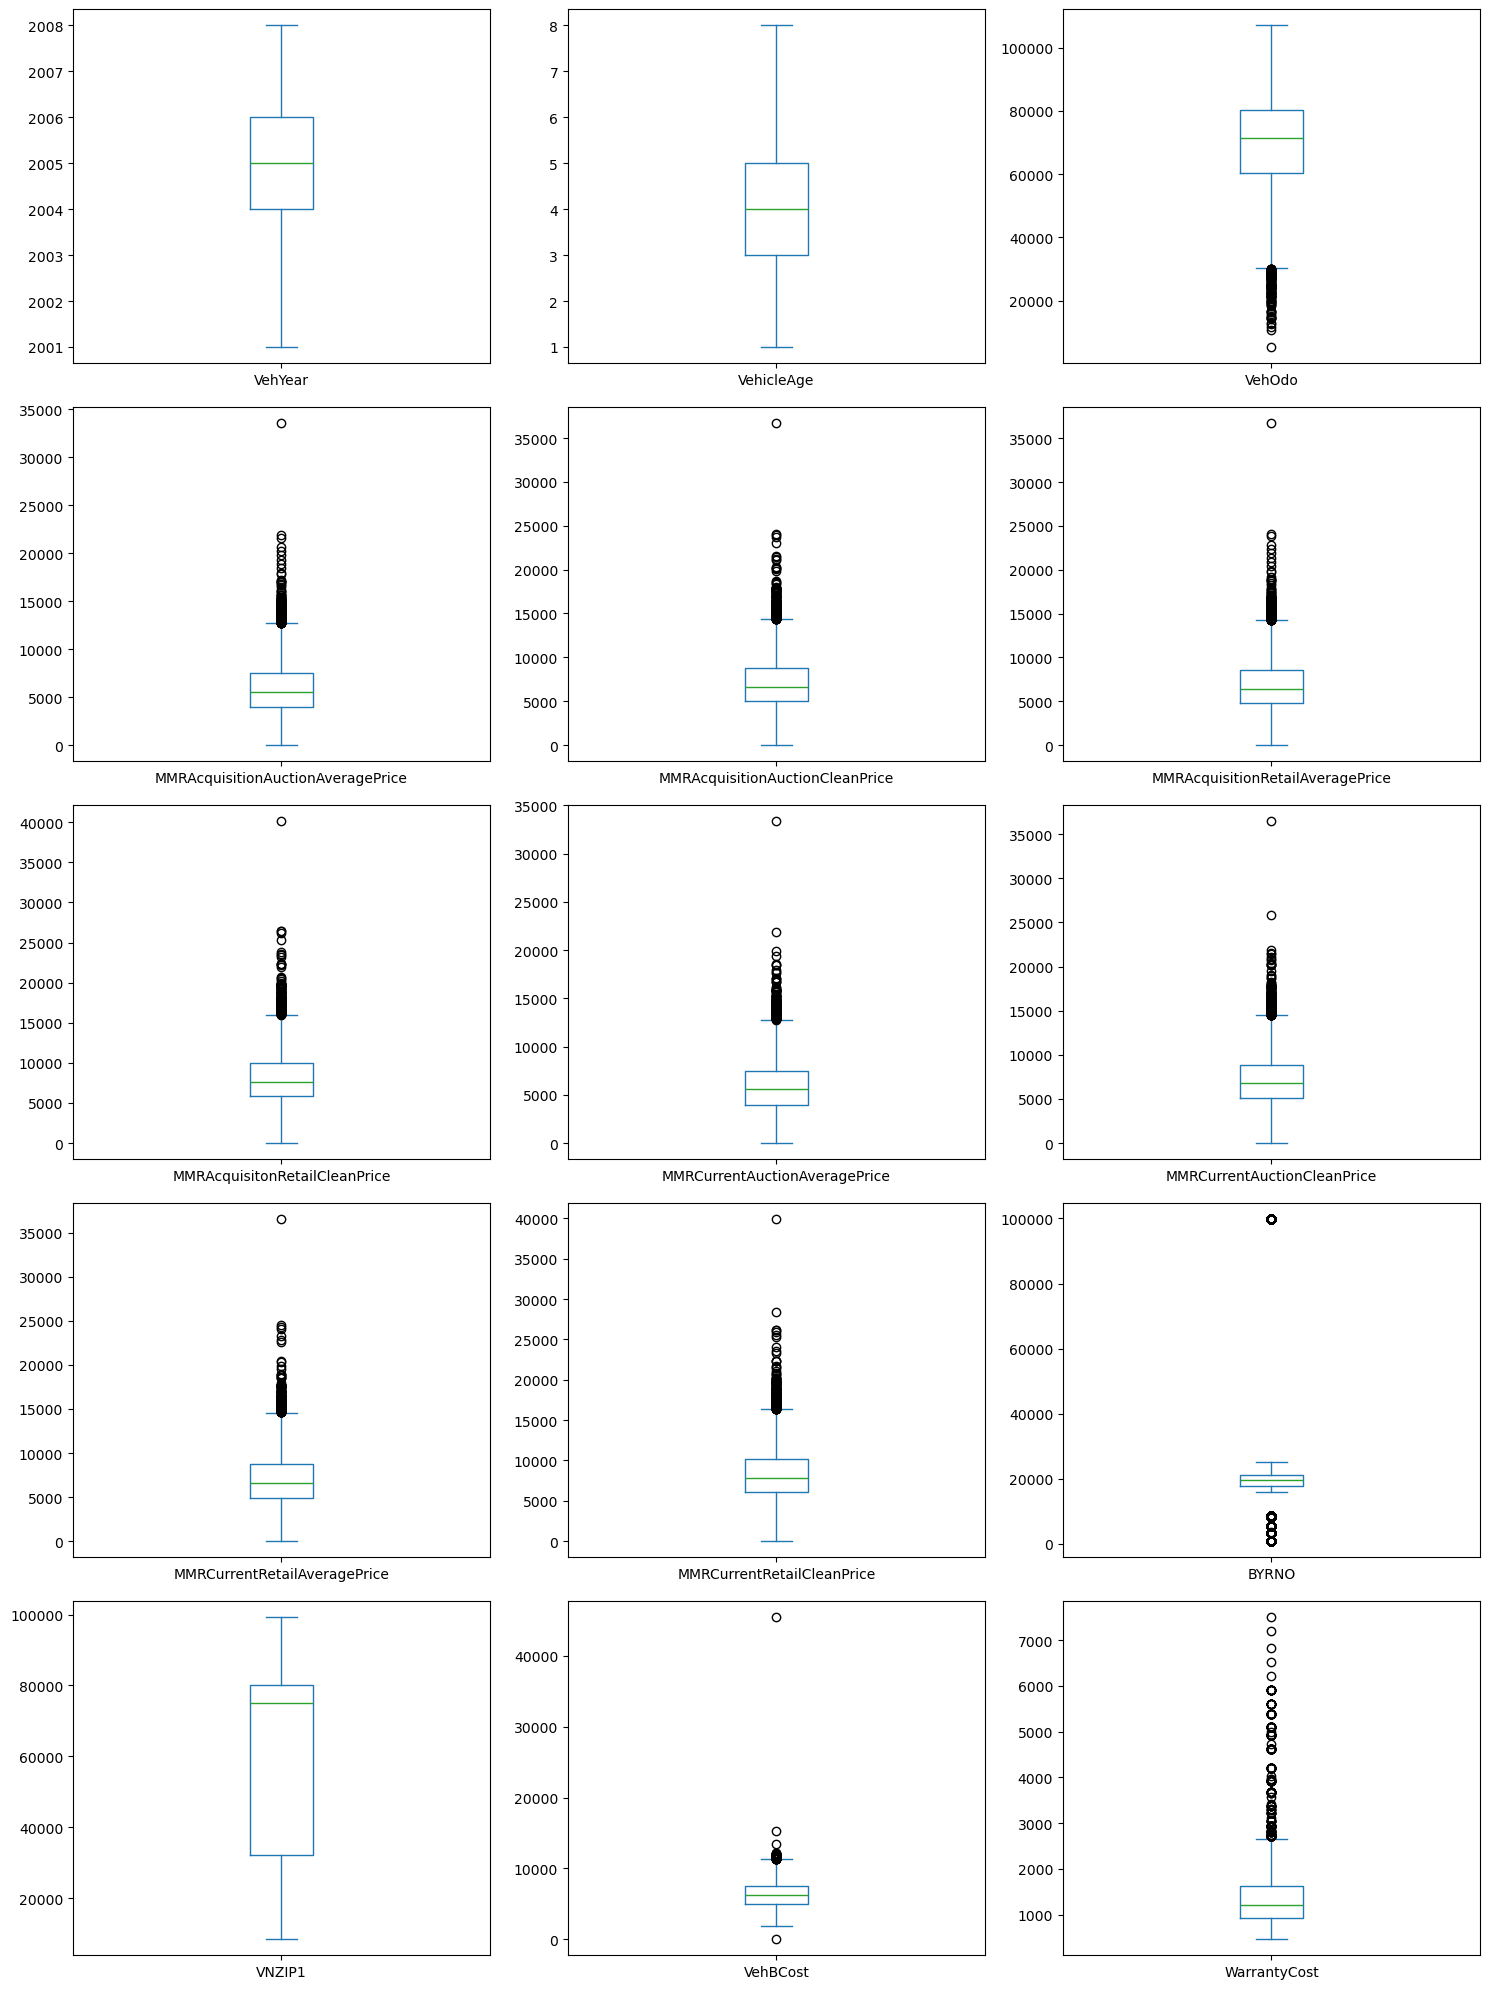

In [31]:
cols = [c for c in train_df_split.select_dtypes('number') if train_df_split[c].nunique() > 2]
train_df_split[cols].plot(kind='box', subplots=True, layout=(-1, 3), figsize=(15, 20))

plt.tight_layout() 
plt.show()

In [32]:
train_df_split[['VehBCost', 'BYRNO', 'VehOdo', 'WarrantyCost']].describe()

,VehBCost,BYRNO,VehOdo,WarrantyCost
count,23059.000000,23059.000000,23059.000000,23059.000000
mean,6341.238978,24292.081964,69737.075155,1320.241511
std,1782.741852,24008.985534,14295.517643,611.197907
min,1.000000,835.000000,5368.000000,462.000000
25%,5000.000000,17675.000000,60318.500000,920.000000
50%,6190.000000,19638.000000,71555.000000,1215.000000
75%,7530.000000,21053.000000,80396.500000,1630.000000
max,45469.000000,99761.000000,107091.000000,7498.000000


**VehBCost** (Стоимость) - минимальное значение цены закупки составляет 1.0. Это является технической ошибкой, такие аномалии в нижней границе могут создать ложные веса при масштабировании данных.

**VehOdo** (Пробег)- данные распределены симметрично, среднее (69,737) практически совпадает с медианой (71,555). Максимальное значение 107,091 находится в пределах разумного для вторичного рынка.

**WarrantyCost** (Стоимость гарантии) - тяжелый хвост в правой части распределения, 75% машин имеют гарантию до 1630$, однако максимум достигает 7498. Данные выбросы могут нести полезную информацию о состоянии авто (дорогая гарантия на проблемные машины), поэтому мы их сохраняем.

In [33]:
pd.Series(train_df_split['VehBCost'].unique()).sort_values().head(10)

470        1.0
1623    1920.0
1616    1960.0
863     2010.0
1365    2060.0
1574    2150.0
849     2200.0
1680    2230.0
1684    2270.0
1246    2280.0
dtype: float64

Разрыв между первым и вторым уникальным значением составляет почти 2000. В интервале от 1 до 1920 данные полностью отсутствуют. Поэтому значение 1.0 не отражает реальную стоимость автомобиля и может негативно повлиять на обучение модели (создать ложное смещение при масштабировании). Для обеспечения стабильности модели выбран порог 1000 (среднее значение этого разрыва), все значения `VehBCost` ниже этого порога будут заменены на медиану обучающей выборки. Это позволит сохранить целостность данных, устранив при этом экстремальный шум.

In [34]:
train_df_split.loc[train_df_split['VehBCost'] < 1000, 'VehBCost'] = train_df_split['VehBCost'].median()
val_df_split.loc[val_df_split['VehBCost'] < 1000, 'VehBCost'] = train_df_split['VehBCost'].median()
test_df_split.loc[test_df_split['VehBCost'] < 1000, 'VehBCost'] = train_df_split['VehBCost'].median()

In [35]:
train_df_split['BYRNO'].nunique()

35

In [36]:
train_df_split.pivot_table(
    index='BYRNO', 
    values='IsBadBuy', 
    aggfunc=['count', 'mean']).sort_values(by=('count', 'IsBadBuy'), ascending=False).head(10)

,count,mean
,IsBadBuy,IsBadBuy
BYRNO,,
3453,1202,0.109817
18880,1166,0.124357
835,1125,0.113778
99750,1125,0.025778
21053,1121,0.113292
22916,1046,0.118547
21973,1013,0.086871
17675,937,0.130203


Всего 35 покупателей совершают тысячи операций. Самый крупный покупатель (ID 34531) приобрел 2020 автомобилей, в то время как другие участники из (ID 18880 и ID 835) совершили более чем по 1100 закупок каждый. Если у покупателя ID 21053 доля брака минимальна и составляет всего 2.5%, то у покупателя ID 17212 этот показатель достигает 16.1%. Такая значительная разница в 6 раз подтверждает, что ID покупателя напрямую влияет на риск покупки плохого авто.

In [37]:
train_df[train_df['VehBCost']==1]['BYRNO'].unique()

array([99761])

In [38]:
train_df[train_df['VehBCost']==1]

,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
878,1,2009-01-19,OTHER,2001,8,DODGE,DAKOTA PICKUP 2WD 4C,Bas,EXT CAB 2.5L,RED,...,2402.0,3440.0,3094.0,4215.0,99761,85018,AZ,1.0,0,1590


In [39]:
train_df.groupby('BYRNO')['VehBCost'].sum().sort_values(ascending=False)

BYRNO
99761    28817765.13
18880    22924740.00
21053    19722811.14
835      19624797.31
3453     19194104.94
            ...     
99760       14400.00
10425        8195.00
1086         8000.00
1157         6560.00
99741        6555.00
Name: VehBCost, Length: 74, dtype: float64

In [40]:
train_df_split['Buyer_Risk'] = train_df_split['BYRNO'].map(train_df_split.groupby('BYRNO')['IsBadBuy'].mean())
val_df_split['Buyer_Risk'] = val_df_split['BYRNO'].map(train_df_split.groupby('BYRNO')['IsBadBuy'].mean())
test_df_split['Buyer_Risk'] = test_df_split['BYRNO'].map(train_df_split.groupby('BYRNO')['IsBadBuy'].mean())

val_df_split['Buyer_Risk'] = val_df_split['Buyer_Risk'].fillna(train_df_split['IsBadBuy'].mean())
test_df_split['Buyer_Risk'] = test_df_split['Buyer_Risk'].fillna(train_df_split['IsBadBuy'].mean())

train_df_split.drop(columns=['BYRNO'], inplace=True)
val_df_split.drop(columns=['BYRNO'], inplace=True)
test_df_split.drop(columns=['BYRNO'], inplace=True)

In [41]:
train_df_split.groupby('Model')['VehBCost'].describe()

,count,mean,std,min,25%,50%,75%,max
Model,,,,,,,,
1500 RAM PICKUP 2WD,358.0,8465.488827,1627.698397,3910.0,7285.00,8812.5,9640.00,11845.0
1500 RAM PICKUP 4WD,19.0,9527.894737,1263.975558,6910.0,8810.00,10100.0,10352.50,11535.0
1500 SIERRA PICKUP 2,50.0,8357.900000,1918.264546,4790.0,7265.00,8652.5,9363.75,12005.0
1500 SIERRA PICKUP 4,1.0,8160.000000,NaN,8160.0,8160.00,8160.0,8160.00,8160.0
1500 SILVERADO PICKU,219.0,8030.821918,1746.345203,3435.0,6832.50,8000.0,9270.00,12035.0
...,...,...,...,...,...,...,...,...
YUKON XL 1500 4WD,3.0,8931.666667,2698.519656,5835.0,8007.50,10180.0,10480.00,10780.0
YUKON XL 1500 4WD 5.,4.0,10158.750000,807.303898,8975.0,10021.25,10440.0,10577.50,10780.0
YUKON XL 1500 AWD 6.,2.0,9732.500000,116.672619,9650.0,9691.25,9732.5,9773.75,9815.0


Ожидаемо цена сильно привязана к модели, cреднее значение (8000–11400) становится нормой для конкретной модели.
Если мы сравниваем фактическую цену `VehBCost` с этой нормой, модель увидит разрыв. Если машина стоит намного дешевле среднего для своей модели это прямой сигнал о риске `IsBadBuy`. 

Создадим признак `Model_Mean_Price`:

In [42]:
model_mean_map = train_df_split.groupby('Model')['VehBCost'].mean()
overall_mean_price = train_df_split['VehBCost'].mean() 

train_df_split['Model_Mean_Price'] = train_df_split['Model'].map(model_mean_map)
val_df_split['Model_Mean_Price'] = val_df_split['Model'].map(model_mean_map)
test_df_split['Model_Mean_Price'] = test_df_split['Model'].map(model_mean_map)

train_df_split['Model_Mean_Price'] = train_df_split['Model_Mean_Price'].fillna(overall_mean_price)
val_df_split['Model_Mean_Price'] = val_df_split['Model_Mean_Price'].fillna(overall_mean_price)
test_df_split['Model_Mean_Price'] = test_df_split['Model_Mean_Price'].fillna(overall_mean_price)

In [43]:
train_df_split.pivot_table(
    index='IsBadBuy', 
    values='VehOdo', 
    aggfunc=['mean', 'median', 'std', 'min', 'max']
)

,mean,median,std,min,max
,VehOdo,VehOdo,VehOdo,VehOdo,VehOdo
IsBadBuy,,,,,
0,69217.756112,71004.0,14312.675861,5368,101588
1,73811.149981,75705.0,13485.810572,11662,107091


- Средний пробег бракованных авто (73811) выше, чем у хороших (69217), разница в 4594 мили. Причиной может быть накопленный износ, чем больше машина была в движении, тем выше вероятность износа деталей.
 - В районе 70–75 тысяч миль у многих машин наступает период планового и часто дорогого обслуживания, вполне возможно, от машин избавляются именно в тот момент, когда они начинают требовать вложений, что и отражается в статистике `IsBadBuy`.
- Минимальные значения: 5368 для хороших и 11662 для плохих. Машины с таким маленьким пробегом большая редкость для площадок, где обычно продают авто с пробегом от 70000. Порог входа в плохие машины (11,6к) почти в два раза выше, чем в хорошие (5,3к). Это может говорить о том, что совсем новые машины (до 10к пробега) попадают в категорию брака значительно реже.
- Возможность технических ошибок, например, пробег 5000 может быть реальным, а может быть пропущенным нулем (вместо 50000). 
- Медиана 75705 выше среднего 73811. Это значит, что большинство машин имеют пробег выше среднего. Хвост из машин с маленьким пробегом (те самые 5к–15к) тянет среднее арифметическое вниз, но типичная машина на аукционе с пробегом от 70000.

In [44]:
train_df_split['Odo_Category'] = train_df_split['VehOdo'].apply(lambda x: 'Пробег < 15k' if x < 15000 else 'Пробег > 15k')

train_df_split.pivot_table(
    index='Odo_Category', 
    values='VehOdo', 
    aggfunc=['count', 'mean']
)
train_df_split = train_df_split.drop('Odo_Category', axis=1)

[Text(0.5, 1.0, 'Распределение пробега')]

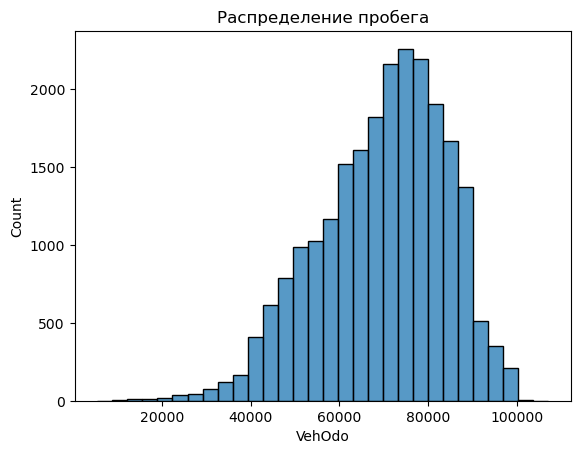

In [45]:
sns.histplot(data=train_df_split, x='VehOdo', bins=30).set(title='Распределение пробега')

Выборка крайне несбалансирована по пробегу, на 23049 стандартных автомобилей приходится всего 10 лотов с пробегом менее 15000 миль. Такая низкая плотность данных в нижнем диапазоне делает невозможным выявление статистических закономерностей для новых авто.

In [46]:
train_df_split['Is_New_Car'] = (train_df_split['VehOdo'] < 15000).astype(int)
val_df_split['Is_New_Car'] = (val_df_split['VehOdo'] < 15000).astype(int)
test_df_split['Is_New_Car'] = (test_df_split['VehOdo'] < 15000).astype(int)

#### WarrantyCost

In [47]:
train_df_split.pivot_table(
    index='WarrantyCost', 
    values='IsBadBuy', 
    aggfunc=['mean', 'count']).sort_index().head(10)

,mean,count
,IsBadBuy,IsBadBuy
WarrantyCost,,
462,0.020548,146
482,0.117647,170
505,0.095785,261
522,0.166667,6
533,0.079872,313
553,0.178571,28
569,0.095385,325
582,0.056604,53


- Низкий ценовой сегмент (462) мы видим минимальный риск, всего 2% (0.0205) при большой выборке в 146 машин. Это самая безопасная категория.
- Высокий ценовой сегмент (594), риск  возрастает до 16.1% (0.1619). Это значит, что каждая шестая машина с такой ценой страховки оказывается проблемной.

`WarrantyCost` - это не просто стоимость услуги, это оценка вероятности поломки. Например, если страховая компания видит надежную модель с прозрачной историей, она ставит минимальную цену. Даже если 2 из 100 машин сломаются, прибыли от остальных 98 с запасом хватит на покрытие ремонта. Для нас это сигнал, что машина почти наверняка в хорошем состоянии. Если же машина сыплется (старый год, плохая репутация модели), страховая видит, что ломаться будет каждая шестая или чаще. Чтобы не уйти в минус на бесконечных ремонтах, они задирают цену страховки в 2-3 раза. **Чем дороже страховка тем выше риск**.

#### Рыночные цены (MMR)

In [48]:
train_df_split.filter(like='MMR').isna().sum()

MMRAcquisitionAuctionAveragePrice      1
MMRAcquisitionAuctionCleanPrice        1
MMRAcquisitionRetailAveragePrice       1
MMRAcquisitonRetailCleanPrice          1
MMRCurrentAuctionAveragePrice        258
MMRCurrentAuctionCleanPrice          258
MMRCurrentRetailAveragePrice         258
MMRCurrentRetailCleanPrice           258
dtype: int64

In [49]:
display(train_df_split.filter(like='MMR').describe())

,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice
count,23058.000000,23058.000000,23058.000000,23058.000000,22801.000000,22801.000000,22801.000000,22801.000000
mean,5781.616792,7008.196808,6737.105213,8061.846214,5847.200649,7093.023552,6902.464936,8250.631244
std,2486.934071,2775.864575,2703.002237,3016.382958,2503.151037,2795.244004,2790.340934,3103.728192
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3940.250000,4989.000000,4756.250000,5888.500000,3986.000000,5082.000000,4851.000000,6034.000000
50%,5500.000000,6616.000000,6440.000000,7645.000000,5571.000000,6767.000000,6585.000000,7879.000000
75%,7462.000000,8740.000000,8559.000000,9939.000000,7508.000000,8850.000000,8751.000000,10170.000000
max,33543.000000,36701.000000,36726.000000,40137.000000,33369.000000,36478.000000,36539.000000,39896.000000


Присутсвуют аномальные нули, **min** везде равен нулю, такого не может быть для автомобиля, если оставить эти нули, они потянут среднее значение вниз.

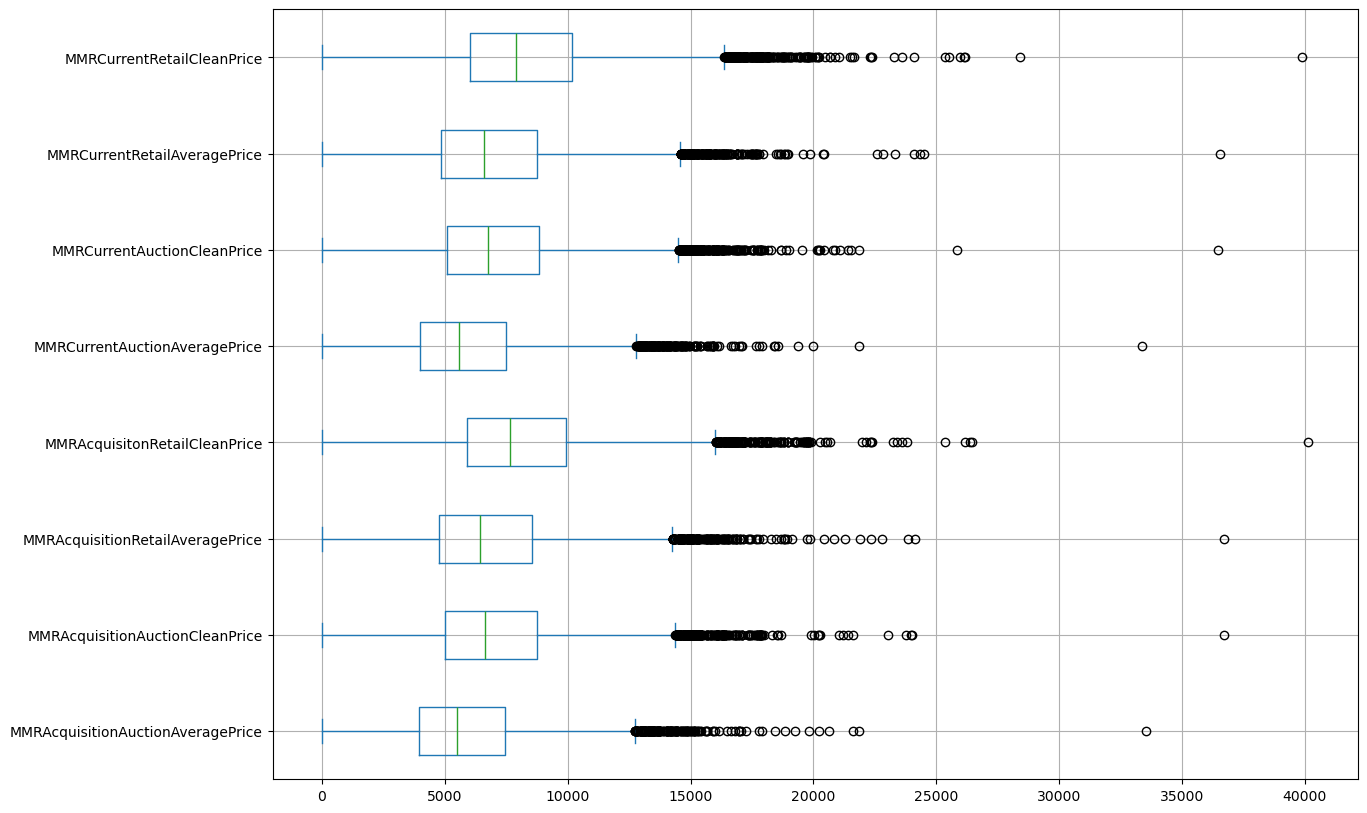

In [50]:
train_df_split.filter(like='MMR').plot(kind='box', vert=False, figsize=(14, 10), grid=True)
plt.show()

На графике видно, что для всех категорий цен `MMRA` наблюдается общая картина с наличием сильных выбросов, где присутсвует скопление точек в диапазоне от 30000 до 40000 $. Это дорогие автомобили, которые сильно отличаются от основной массы.

Также можно наблюдать положительную асимметрию, где среднее значение во всех колонках стабильно выше медианы (50%) примерно на 300–400 $. Это подтверждает, что выбросы тянут среднее арифметическое вверх.
Аномальные нули, где минимальные значения цен нулевые, что для рыночных цен MMR является технической ошибкой или отсутствием данных в базе на момент выгрузки.

Для заполнения пропусков используем median, так как она устойчива к выбросам и лучше описывает типичную цену автомобиля в данном случае.
Нулевые цены заполним NaN и после медианой, чтобы исключить искажение прогнозов модели:

In [51]:
mmr_medians = train_df_split.filter(like='MMR').replace(0, np.nan).median()

for mmr in [train_df_split, val_df_split, test_df_split]:
    mmr.update(mmr.filter(like='MMR').replace(0, np.nan).fillna(mmr_medians))

In [52]:
train_df_split.filter(like='MMR').describe()

,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice
count,23059.000000,23059.000000,23059.000000,23059.000000,23059.000000,23059.000000,23059.000000,23059.000000
mean,5860.692571,7065.308513,6829.634936,8171.692181,5926.202784,7151.175680,6995.685286,8363.099094
std,2387.924717,2698.363562,2578.880285,2856.681573,2386.223140,2696.000339,2645.738181,2919.900207
min,884.000000,1.000000,1455.000000,1662.000000,369.000000,1.000000,899.000000,1034.000000
25%,4021.000000,5019.000000,4843.000000,5976.000000,4110.000000,5175.000000,4971.000000,6162.500000
50%,5543.000000,6653.000000,6486.000000,7700.000000,5616.000000,6790.000000,6628.000000,7963.000000
75%,7462.000000,8740.000000,8559.000000,9939.000000,7500.000000,8822.000000,8698.500000,10148.000000
max,33543.000000,36701.000000,36726.000000,40137.000000,33369.000000,36478.000000,36539.000000,39896.000000


Сравним фактическую цену покупки автомобиля на аукционе `VehBCost` со средней рыночной ценой на момент закупки `MMRAcquisitionAuctionAveragePrice`. Это позволит нам понять, насколько сильно реальные сделки отклоняются от рыночных ожиданий, так как аномальные отклонения (слишком дешевые или слишком дорогие покупки) могут быть индикаторами скрытых проблем автомобиля.

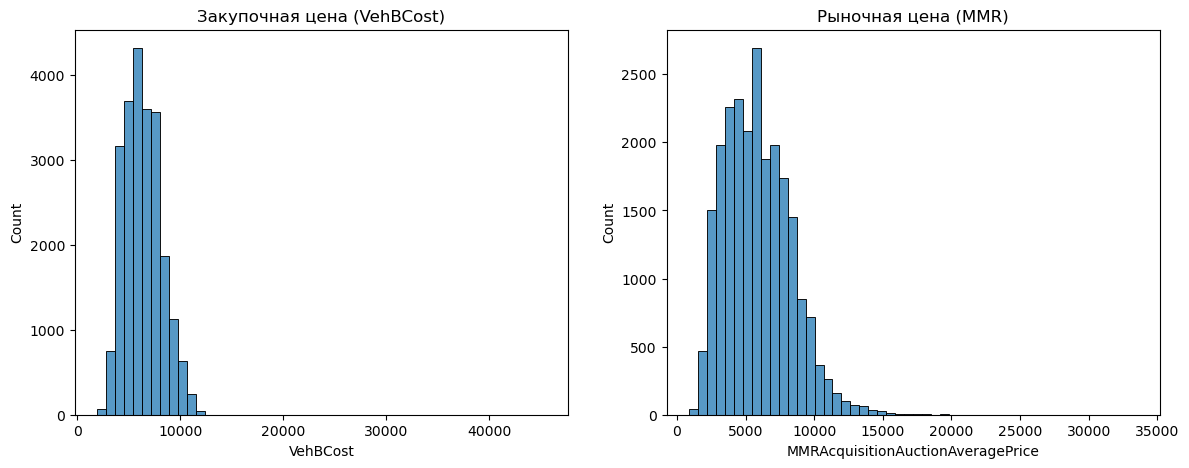

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df_split['VehBCost'], bins=50, ax=axes[0])
axes[0].set_title('Закупочная цена (VehBCost)')
sns.histplot(train_df_split['MMRAcquisitionAuctionAveragePrice'], bins=50, ax=axes[1])
axes[1].set_title('Рыночная цена (MMR)')

plt.show()

Распределения обеих цен имеют схожую форму, однако заметно, что закупочная цена `VehBCost` часто смещена относительно рыночной (основная масса сделок сосредоточена в узком диапазоне от **5000**). Наличие хвостов подтверждает, что в данных есть машины, купленные значительно дешевле или дороже рынка (пик рыночной цены MMR также находится в районе **5000**, но гораздо более длинный хвост в сторону высоких цен (до **15000**).

In [54]:
mmr_cols = ['MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice',
            'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice',
            'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice',
            'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice']

train_df_split['MMR_Final'] = train_df_split[mmr_cols].median(axis=1)
val_df_split['MMR_Final']   = val_df_split[mmr_cols].median(axis=1)
test_df_split['MMR_Final']  = test_df_split[mmr_cols].median(axis=1)

display(train_df_split[['VehBCost', 'MMR_Final']].head())

,VehBCost,MMR_Final
0,6770.0,9381.5
1,6160.0,5767.5
2,4250.0,4115.0
3,8180.0,10160.5
4,4900.0,4184.5


#### Auction

In [55]:
train_df_split.groupby('Auction')['IsBadBuy'].mean().sort_values(ascending=False).to_frame()

,IsBadBuy
Auction,
ADESA,0.151321
MANHEIM,0.103381
OTHER,0.103016


Площадка ADESA является статистически значимым фактором риска (доля проблемных автомобилей IsBadBuy на ней составляет 15 %, что почти на 5% выше, чем у площадок MANHEIM и OTHER (~10.5%)).

In [56]:
print(train_df_split.groupby('Transmission')['IsBadBuy'].agg(['mean', 'count']))

                  mean  count
Transmission                 
AUTO          0.113401  22416
MANUAL        0.100787    635
UNKNOWN       0.125000      8


Проанализируем, как связаны между собой производитель, модель и комплектация, так как такие уникальные сочетания могут по-разному влиять на риск покупки "лимона"

In [57]:
train_df_split[train_df_split['Make'] == train_df_split['Make'].mode()[0]].groupby(['Model', 'SubModel', 'Trim']).size().nlargest(15)

Model                 SubModel            Trim
IMPALA 3.5L V6 SFI    4D SEDAN LS         LS      513
IMPALA 3.4L V6 SFI    4D SEDAN            Bas     429
MALIBU 4C 2.2L I4 MP  4D SEDAN LT         LT      241
                      4D SEDAN CLASSIC    Cla     237
MALIBU V6 3.5L V6 SF  4D SEDAN LS         LS      142
CAVALIER 4C 2.2L I4   4D SEDAN            Bas     141
TRAILBLAZER 4WD 6C 4  4D SUV 4.2L LS      LS      140
IMPALA 3.5L V6 SFI    4D SEDAN LT 3.5L    LT      131
COBALT 2.2L I4 MPI    4D SEDAN LS         LS      129
TRAILBLAZER 2WD 6C 4  4D SUV 4.2L         LS      122
                      4D SUV 4.2L LS      LS      101
                                          Nor      98
UPLANDER FWD V6 3.5L  PASSENGER EXT 3.5L  LS       96
IMPALA V6 3.5L V6 SF  4D SEDAN LT 3.5L    LT       85
EQUINOX FWD V6 3.4L   4D SUV LS           LS       84
dtype: int64

Признаки `Model`, `SubModel` и `Trim` сильно взаимосвязаны и детально описывают модификацию автомобиля, например:
- Модель IMPALA с двигателем 3.5L встречается как в комплектации LS, так и LT
- У модели MALIBU есть четкое разделение по кузову: 4D SEDAN LT и 4D SEDAN CLASSIC. Это разные поколения машин, которые могут иметь разную надежность
- Внедорожник TRAILBLAZER представлен версиями с разным приводом (2WD и 4WD), что напрямую влияет на его стоимость

#### Color
Выведем процент "лимонов" для каждого цвета.

In [58]:
train_df_split.groupby('Color')['IsBadBuy'].mean().sort_values(ascending=False)

Color
BROWN        0.151899
BEIGE        0.144737
GOLD         0.139058
RED          0.127225
MAROON       0.121387
GREEN        0.116056
SILVER       0.112542
GREY         0.109844
BLUE         0.105425
WHITE        0.104161
BLACK        0.102660
OTHER        0.102041
ORANGE       0.092784
NOT AVAIL    0.087719
YELLOW       0.084337
PURPLE       0.068627
Name: IsBadBuy, dtype: float64

In [59]:
train_df_split['IsBadBuy'].value_counts()

IsBadBuy
0    20452
1     2607
Name: count, dtype: int64

- BROWN, BEIGE и GOLD имеют самый высокий процент `IsBadBuy` (около 14-15%)
- PURPLE, YELLOW и ORANGE имеют риск ниже среднего (7-9%)
- WHITE, BLACK, SILVER находятся в середине с риском около 10-11%

In [60]:
train_df_split.pivot_table(
    index='Color', 
    values='IsBadBuy', 
    aggfunc=['mean', 'count']).sort_values(('mean', 'IsBadBuy'), ascending=False)

,mean,count
,IsBadBuy,IsBadBuy
Color,,
BROWN,0.151899,158
BEIGE,0.144737,456
GOLD,0.139058,1805
RED,0.127225,1910
MAROON,0.121387,692
GREEN,0.116056,1146
SILVER,0.112542,4736
GREY,0.109844,2367


In [61]:
train_df_split[train_df_split['Make'].isin(train_df_split['Make'].value_counts().head(5).index)].pivot_table(
    index='Make', 
    columns='Color', 
    values='IsBadBuy', 
    aggfunc='mean')

Color,BEIGE,BLACK,BLUE,BROWN,GOLD,GREEN,GREY,MAROON,NOT AVAIL,ORANGE,OTHER,PURPLE,RED,SILVER,WHITE,YELLOW
Make,,,,,,,,,,,,,,,,
CHEVROLET,0.101695,0.115813,0.081356,0.116279,0.105172,0.108374,0.097682,0.097087,0.0,0.153846,0.041667,0.000000,0.125000,0.084392,0.085354,0.047619
CHRYSLER,0.162162,0.088710,0.119141,0.000000,0.099379,0.141593,0.092308,0.085714,0.0,0.000000,0.000000,0.106383,0.126263,0.118827,0.072973,0.000000
DODGE,0.063492,0.075472,0.075450,0.222222,0.089385,0.041322,0.083151,0.144444,0.0,0.075000,0.071429,0.142857,0.102138,0.086288,0.094749,0.100000
FORD,0.183908,0.119593,0.141204,0.217391,0.191223,0.152381,0.141243,0.135338,0.4,0.333333,0.200000,0.000000,0.174863,0.145714,0.133333,0.142857
PONTIAC,0.200000,0.067797,0.116279,0.166667,0.211679,0.200000,0.085890,0.130435,0.5,0.111111,0.000000,NaN,0.093023,0.099042,0.109375,NaN


- У некоторых марок определенные цвета показывают аномально высокий риск. Например, BROWN у марки DODGE (22%) и FORD (21%) значительно опаснее, чем у других брендов. Это подтверждает, что цвет может служить маркером специфического использования (например, корпоративные или сервисные авто определенных цветов).
- У бренда FORD отсутствие данных о цвете (NOT AVAIL) коррелирует с крайне высоким риском брака (40%), в то время как у других марок этот показатель равен нулю. Это критически важный сигнал, который модель должна учитывать.

Поэтому можно сделать вывод, что риск для одного и того же цвета (например, BEIGE) может варьироваться от 6% (Dodge) до 20% (Pontiac).

#### VehicleAge

In [62]:
train_df_split.pivot_table(index='VehicleAge', values='IsBadBuy', aggfunc=['mean', 'count'])

,mean,count
,IsBadBuy,IsBadBuy
VehicleAge,,
1,0.046243,865
2,0.054482,2019
3,0.066581,5467
4,0.103307,5866
5,0.130818,4082
6,0.177863,2620
7,0.211859,1501
8,0.264476,639


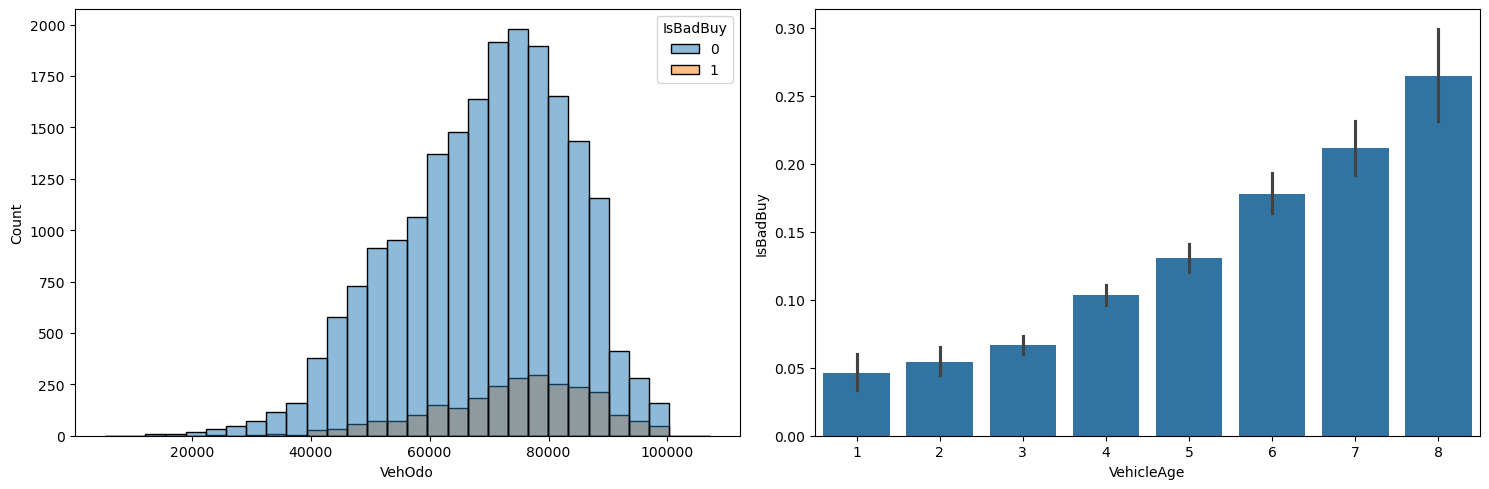

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=train_df_split, x='VehOdo', hue='IsBadBuy', bins=30, ax=axes[0])
sns.barplot(data=train_df_split, x='VehicleAge', y='IsBadBuy', ax=axes[1], )

plt.tight_layout()
plt.show()

**VehOdo (Пробег)** - нормальная форма распределения, пик в районе 70000–80000 миль, что является критической точкой, так как именно при таком пробеге дилеры массово сбрасывают машины на аукцион. Можно заметить, что доля риска (IsBadBuy = 1) распределены почти так же, как (IsBadBuy = 1), поэтмоу можно сделать вывод, что сам по себе большой пробег не приговор. Есть много машин с пробегом 90000+, которые 'хорошие', и есть машины с пробегом 40000, которые уже 'лимоны'.

**VehicleAge (Возраст)** - ожидаемая восходящая линия. До 3 лет риск плохой покупки почти минимален (около 5 %), после 4 лет риск увеличивается. При возрасте автомобиля 8-9 лет риск плохой покупки почти в 6 раз выше.

Поэтому можно предположить, что важен не просто пробег, а его интенсивность. Машина может быть новой, но с огромным пробегом за короткий срок (признак такси или коммерческого использования), что повышает риск скрытых дефектов.

In [64]:
train_df_split['OdoPerYear'] = train_df_split['VehOdo'] / (train_df_split['VehicleAge'] + 1)
val_df_split['OdoPerYear'] = val_df_split['VehOdo'] / (val_df_split['VehicleAge'] + 1)
test_df_split['OdoPerYear'] = test_df_split['VehOdo'] / (test_df_split['VehicleAge'] + 1)

In [65]:
train_df_split.groupby('IsBadBuy')['OdoPerYear'].mean().reset_index()

,IsBadBuy,OdoPerYear
0,0,14779.092308
1,1,13373.201632


Мы видим, что у хороших машин (IsBadBuy = 0) средний годовой пробег выше (около 14500), чем у плохих (IsBadBuy = 1, около 13500). Получается, что машины, которые ездили меньше в год, оказываются "лимонами" чаще, объясняется это тем, что если машина долго стояла без движения, то механически она изнашивается быстрее, или же на ней ездили на очень короткие дистанции, что убивает мотор быстрее.

Поэтому признак `OdoPerYear` в данном случае будет работать наоборот: малый годовой пробег при большом возрасте это риск плохой покупки.

#### Нормализация распределения

In [66]:
log_cols = ['VehOdo', 'VehBCost', 'WarrantyCost', 'MMR_Final', 'Model_Mean_Price']

for col in log_cols:
    train_df_split[col] = np.log1p(train_df_split[col])
    val_df_split[col]   = np.log1p(val_df_split[col])
    test_df_split[col]  = np.log1p(test_df_split[col])

for col in mmr_cols:
    train_df_split[col] = np.log1p(train_df_split[col])
    val_df_split[col]   = np.log1p(val_df_split[col])
    test_df_split[col]  = np.log1p(test_df_split[col])

train_df_split['Price_Diff'] = train_df_split['MMR_Final'] - train_df_split['VehBCost']
val_df_split['Price_Diff']   = val_df_split['MMR_Final'] - val_df_split['VehBCost']
test_df_split['Price_Diff']  = test_df_split['MMR_Final'] - test_df_split['VehBCost']

train_df_split['Model_Price_Diff'] = train_df_split['Model_Mean_Price'] - train_df_split['VehBCost']
val_df_split['Model_Price_Diff']   = val_df_split['Model_Mean_Price'] - val_df_split['VehBCost']
test_df_split['Model_Price_Diff']  = test_df_split['Model_Mean_Price'] - test_df_split['VehBCost']

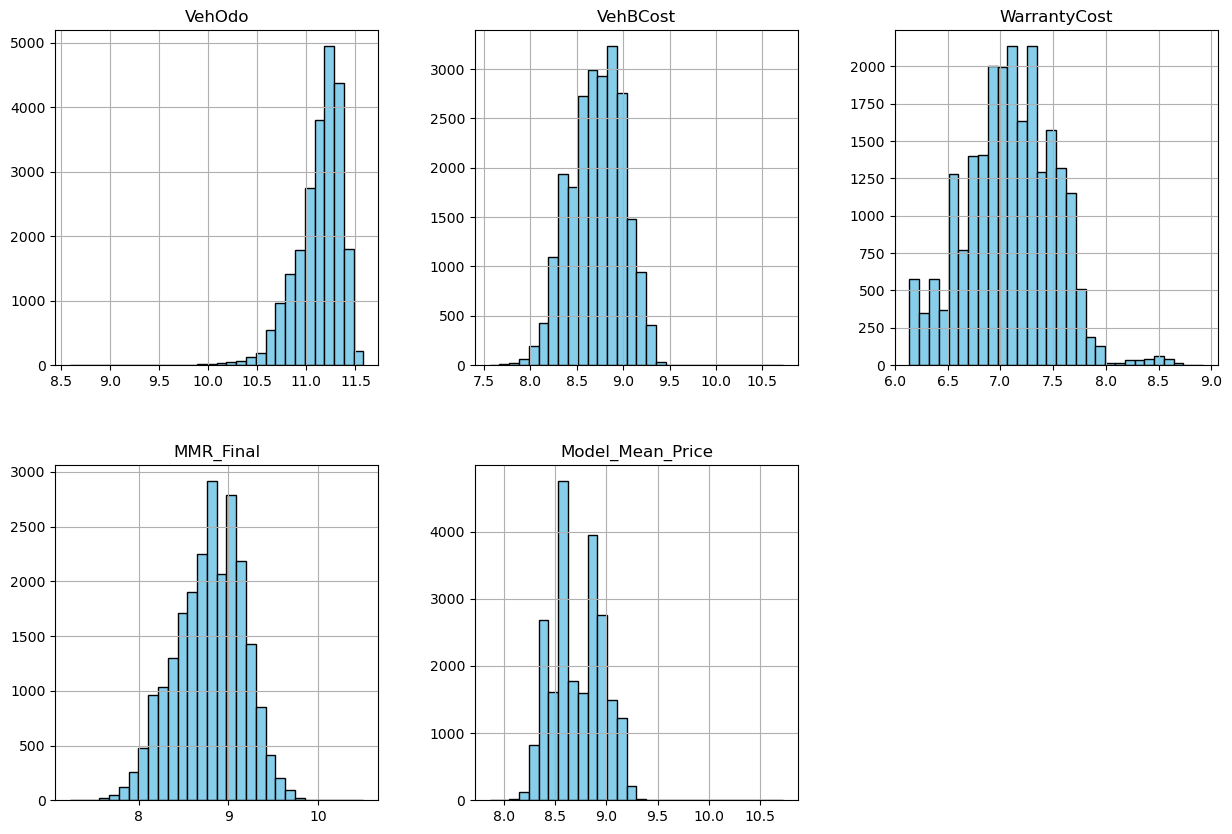

In [67]:
train_df_split[log_cols].hist(bins=30, figsize=(15, 10), layout=(2, 3), color='skyblue', edgecolor='black')
plt.show()

In [68]:
new_features = ['Price_Diff', 'OdoPerYear', 'Is_New_Car', 'Buyer_Risk', 'MMR_Final', 'Model_Mean_Price']

##### 3. Используем OneHotEncoder и Frequency Encoder для предварительной обработки категориальных переменных.

In [69]:
train_analysis = train_df_split.copy()
val_analysis   = val_df_split.copy()
test_analysis  = test_df_split.copy()

In [70]:
ohe_features = ['Size', 'TopThreeAmericanName', 'Nationality', 'Transmission', 'WheelType', 'Auction', 'Color']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(train_df_split[ohe_features])

ohe_cols = encoder.get_feature_names_out(ohe_features)

train_df_split[ohe_cols] = encoder.transform(train_df_split[ohe_features])
val_df_split[ohe_cols]   = encoder.transform(val_df_split[ohe_features])
test_df_split[ohe_cols]  = encoder.transform(test_df_split[ohe_features])

train_df_split.drop(columns=ohe_features, inplace=True)
val_df_split.drop(columns=ohe_features, inplace=True)
test_df_split.drop(columns=ohe_features, inplace=True)

Для категориальных признаков с высокой мощностью (большим количеством уникальных значений), таких как Make, Model, SubModel, Trim, VNST и VNZIP1, применяется Count Encoding. Мы заменяем название категории на частоту её появления в обучающей выборке.

In [71]:
count_cols = ['Make', 'Model', 'SubModel', 'Trim', 'VNST', 'VNZIP1']

for col in count_cols:
    counts = train_df_split[col].value_counts()
    
    train_df_split[col] = train_df_split[col].map(counts)
    val_df_split[col]   = val_df_split[col].map(counts).fillna(0)
    test_df_split[col]  = test_df_split[col].map(counts).fillna(0)

## Обучение моделей Sklearn и реализация Gini
##### 4. Обучение LogisticRegression, GaussianNB и KNN из sklearn на обучающем наборе данных и проверка качества на валидационном наборе данных. Зависимая переменная (IsBadBuy) является бинарной.

In [72]:
feature_cols = train_df_split.columns.drop(['IsBadBuy', 'PurchDate'] + new_features)

X_train = train_df_split[feature_cols]
y_train = train_df_split['IsBadBuy']

X_val = val_df_split[feature_cols]
y_val = val_df_split['IsBadBuy']

X_test = test_df_split[feature_cols]
y_test = test_df_split['IsBadBuy']

In [73]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [74]:
def learning_models(model, name, X_train_scaled, y_train, X_val_scaled, y_val):
    model.fit(X_train_scaled, y_train)
    
    probs = model.predict_proba(X_val_scaled)
    try:
        probabilities = probs[:, 1]
    except (IndexError, TypeError):
        probabilities = probs
    gini = abs(2 * roc_auc_score(y_val, probabilities) - 1)
    
    metrics_utils.add_metric(name, gini)
    print(f"{name:}: {gini:.4f}")

    return model

In [75]:
model_lr = learning_models(
    LogisticRegression(class_weight='balanced', random_state=21), 
    'LogisticRegression', X_train_scaled, y_train, X_val_scaled, y_val)

model_nb = learning_models(
    GaussianNB(), 
    'GaussianNB', X_train_scaled, y_train, X_val_scaled, y_val)

model_knn = learning_models(
    KNeighborsClassifier(n_neighbors=1000, weights='distance'), 
    'KNeighborsClassifier', X_train_scaled, y_train, X_val_scaled, y_val)

LogisticRegression: 0.4790
GaussianNB: 0.4160
KNeighborsClassifier: 0.4683


In [76]:
metrics_utils.results_df

,model,gini_score
0,LogisticRegression,0.4790
1,GaussianNB,0.4160
2,KNeighborsClassifier,0.4683


- **Logistic Regression (0.47)** лучше всего уловила сильные линейные зависимости в данных (например, прямую связь между возрастом авто/стоимостью гарантии и риском брака). 
- **Gaussian NB (~0.41)**
подтверждает наличие независимых сигналов в признаках. Однако точность ограничена тем, что не все данные распределены нормально (есть перекосы в пробеге и ценах), а модель не учитывает взаимосвязи между признаками.
- **KNeighbors Classifier (~0.32)** 
крайне чувствителен к шуму и редким значениям в хвостах распределений. Даже при использовании StandardScaler, наличие единичных записей (например, авто с очень низким пробегом) искажает понятие соседства, заставляя модель ошибаться в прогнозах.

*Примечание: показатель Gini реализован в модуле **gini.py***

##### 5. Реализуем расчет показателя Gini, используя подход 2*ROC AUC - 1, поэтому необходимо реализовать расчет ROC AUC. Сравнение кастомной метрики с abs(2*sklearn.metrics.roc_auc_score - 1).

In [77]:
results = []

for m in [model_lr, model_nb, model_knn]:
    y_probs = m.predict_proba(X_val_scaled)[:, 1]
    
    sk_gini = abs(2 * roc_auc_score(y_val, y_probs) - 1)
    my_gini = custom_gini(y_val, y_probs)
    
    results.append({
        'Model': type(m).__name__,
        'Sklearn_Gini': sk_gini,
        'Custom_Gini': my_gini,
        'Difference': round(abs(my_gini - sk_gini), 2)
    })
    
pd.DataFrame(results).set_index('Model')

,Sklearn_Gini,Custom_Gini,Difference
Model,,,
LogisticRegression,0.479032,0.479032,0.0
GaussianNB,0.415962,0.415962,0.0
KNeighborsClassifier,0.468321,0.468321,0.0


----

## Реализация собственных версий классификаторов
*Примечание: все версии классификаторов реализованы в модулях **logistic_regression.py**, **naive_bayes.py** и **knn.py***

##### 6. Реализация собственных версий классификаторов LogisticRegression, KNN и NaiveBayes. Для LogisticRegression вычислим градиенты относительно функции потерь и используем SGD. 
*Рекомендации для этой задачи: Модель должна быть представлена классом с методами *fit , predict ( predict_proba с порогом 0,5 ), predict_proba*. Для модели LR вычислим градиент функции потерь относительно параметров w и b в функции fit. Используем подход SGD для оценки оптимальных значений параметров.*

In [78]:
model_my_lr = learning_models(
    MyLogisticRegression(lr=0.01, epochs=20, batch_size=64, random_state=21), 
    'Custom_LogisticRegression', 
    X_train_scaled, y_train, X_val_scaled, y_val
)

model_my_nb = learning_models(
    MyNaiveBayes(), 
    'Custom_GaussianNB', 
    X_train_scaled, y_train, X_val_scaled, y_val
)

model_my_knn = learning_models(
    MyKNN(k=1000), 
    'Custom_KNeighborsClassifier', 
    X_train_scaled, y_train, X_val_scaled, y_val
)

Custom_LogisticRegression: 0.4722
Custom_GaussianNB: 0.4162
Custom_KNeighborsClassifier: 0.4656


- **Logistic Regression** небольшое снижение метрики Gini, так как в кастомную модель не добавлялась регуляризация (штрафы за веса), а оптимизация шла обычными итерациями градиентного спуска. Это привело к менее точной настройке весов по сравнению с библиотечным оптимизатором.
- **Naive Bayes** основан на строгой математической формуле вероятности. Благодаря StandardScaler, классы получились четкими, что позволило ручной реализации отработать без потери качества.
- **KNN** показал высокий Gini, сопоставимый с шагом 4, но работал значительно медленнее. Кастомная реализация использует полный перебор всей обучающей выборки для каждого предсказания.

##### 7. Попробуем создать нелинейные признаки, например: 
*доли: признак1/признак2, сгруппированные по признакам: 
df[‘categorical_feature’].map(df.groupby(‘categorical_feature’)[‘continious_feature’].mean())*


Данный этап был выполнен в разделе предобработки данных, но не добавлялся в обучение. Созданные признаки: `Price_Diff`, `OdoPerYear`, `Is_New_Car`, `Buyer_Risk`, `MMR_Final`, `Model_Mean_Price`

In [79]:
feature_cols = train_df_split.columns.drop(['IsBadBuy', 'PurchDate'])

X_train = train_df_split[feature_cols]
y_train = train_df_split['IsBadBuy']

X_val = val_df_split[feature_cols]
y_val = val_df_split['IsBadBuy']

X_test = test_df_split[feature_cols]
y_test = test_df_split['IsBadBuy']

In [80]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [81]:
model_lr = learning_models(
    LogisticRegression(class_weight='balanced', random_state=21), 
    'LogisticRegression', X_train_scaled, y_train, X_val_scaled, y_val)

model_nb = learning_models(
    GaussianNB(), 
    'GaussianNB', X_train_scaled, y_train, X_val_scaled, y_val)

model_knn = learning_models(
    KNeighborsClassifier(n_neighbors=1000, weights='distance'), 
    'KNeighborsClassifier', X_train_scaled, y_train, X_val_scaled, y_val)

LogisticRegression: 0.4791
GaussianNB: 0.4256
KNeighborsClassifier: 0.4715


In [82]:
metrics_utils.results_df

,model,gini_score
0,LogisticRegression,0.4791
1,GaussianNB,0.4256
2,KNeighborsClassifier,0.4715
3,Custom_LogisticRegression,0.4722
4,Custom_GaussianNB,0.4162
5,Custom_KNeighborsClassifier,0.4656


## Оптимизация гиперпараметров и итоговое тестирование
##### 8. Определим наиболее подходящие признаки для решения задачи, используя коэффициенты логистической модели. Исключим бесполезные признаки вручную и с помощью L1-регуляризации. Какой подход лучше с точки зрения коэффициента Джини?

#### Manual selection (SHAP)

In [83]:
shap_drop = pd.DataFrame(shap.LinearExplainer(model_lr, X_train_scaled)(X_val_scaled).values, 
             columns=X_train.columns).abs().mean().sort_values().head(20)
shap_drop

IsOnlineSale                     0.000000
Color_NOT AVAIL                  0.000080
Transmission_UNKNOWN             0.000156
Is_New_Car                       0.000202
WheelType_Special                0.000271
Color_YELLOW                     0.001348
Color_BEIGE                      0.001638
Nationality_OTHER                0.001734
Color_MAROON                     0.002093
Size_SPORTS                      0.002498
Color_OTHER                      0.002647
Size_MEDIUM                      0.002651
Size_SMALL SUV                   0.003077
Size_CROSSOVER                   0.003080
Color_PURPLE                     0.003395
Size_LARGE SUV                   0.003463
Nationality_OTHER ASIAN          0.004127
Color_BROWN                      0.004190
TopThreeAmericanName_CHRYSLER    0.004338
Nationality_TOP LINE ASIAN       0.004686
dtype: float64

In [84]:
shap_drop = shap_drop.index.tolist()
feature_cols = train_df_split.columns.drop(['IsBadBuy', 'PurchDate'] + shap_drop)

X_train = train_df_split[feature_cols]
y_train = train_df_split['IsBadBuy']

X_val = val_df_split[feature_cols]
y_val = val_df_split['IsBadBuy']

X_test = test_df_split[feature_cols]
y_test = test_df_split['IsBadBuy']

In [85]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [86]:
metrics_utils.results_df

,model,gini_score
0,LogisticRegression,0.4791
1,GaussianNB,0.4256
2,KNeighborsClassifier,0.4715
3,Custom_LogisticRegression,0.4722
4,Custom_GaussianNB,0.4162
5,Custom_KNeighborsClassifier,0.4656


In [87]:
model_lr = learning_models(
    LogisticRegression(class_weight='balanced', random_state=21), 
    'LogisticRegression_shap', X_train_scaled, y_train, X_val_scaled, y_val)

model_nb = learning_models(
    GaussianNB(), 
    'GaussianNB_shap', X_train_scaled, y_train, X_val_scaled, y_val)

model_knn = learning_models(
    KNeighborsClassifier(n_neighbors=1000, weights='distance'), 
    'KNeighborsClassifier_shap', X_train_scaled, y_train, X_val_scaled, y_val)

LogisticRegression_shap: 0.4811
GaussianNB_shap: 0.4576
KNeighborsClassifier_shap: 0.4806


#### L1-регуляризация

In [88]:
feature_cols = train_df_split.columns.drop(['IsBadBuy', 'PurchDate'])

X_train = train_df_split[feature_cols]
y_train = train_df_split['IsBadBuy']

X_val = val_df_split[feature_cols]
y_val = val_df_split['IsBadBuy']

X_test = test_df_split[feature_cols]
y_test = test_df_split['IsBadBuy']

In [89]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [90]:
model_l1 = learning_models(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=0.01, random_state=21), 
    'LogisticRegression_selection', 
    X_train_scaled, y_train, X_val_scaled, y_val
)

selected_features = feature_cols[model_l1.coef_[0] != 0]
excluded_features = feature_cols[model_l1.coef_[0] == 0]

LogisticRegression_selection: 0.4858


In [91]:
print(*excluded_features, sep='\n')

Make
MMRAcquisitionAuctionAveragePrice
MMRAcquisitionAuctionCleanPrice
MMRAcquisitionRetailAveragePrice
MMRAcquisitonRetailCleanPrice
MMRCurrentAuctionAveragePrice
MMRCurrentAuctionCleanPrice
MMRCurrentRetailAveragePrice
MMRCurrentRetailCleanPrice
VNST
IsOnlineSale
Model_Mean_Price
MMR_Final
OdoPerYear
Price_Diff
Model_Price_Diff
Size_COMPACT
Size_CROSSOVER
Size_LARGE
Size_LARGE SUV
Size_MEDIUM
Size_SMALL SUV
TopThreeAmericanName_CHRYSLER
TopThreeAmericanName_OTHER
Nationality_AMERICAN
Nationality_OTHER ASIAN
Nationality_TOP LINE ASIAN
Transmission_MANUAL
WheelType_Alloy
Auction_ADESA
Auction_OTHER
Color_BEIGE
Color_BLACK
Color_BLUE
Color_GREEN
Color_GREY
Color_MAROON
Color_NOT AVAIL
Color_ORANGE
Color_SILVER


In [92]:
X_train_scaled = scaler.fit_transform(train_df_split[selected_features])
X_val_scaled = scaler.transform(val_df_split[selected_features])

model_nb_fs = learning_models(
    GaussianNB(), 
    'GaussianNB_selection', X_train_scaled, y_train, X_val_scaled, y_val)

model_knn_fs = learning_models(
    KNeighborsClassifier(n_neighbors=1000, weights='distance'), 
    'KNeighborsClassifier_selection', X_train_scaled, y_train, X_val_scaled, y_val)

GaussianNB_selection: 0.4312
KNeighborsClassifier_selection: 0.4845


In [93]:
metrics_utils.results_df

,model,gini_score
0,LogisticRegression,0.4791
1,GaussianNB,0.4256
2,KNeighborsClassifier,0.4715
3,Custom_LogisticRegression,0.4722
4,Custom_GaussianNB,0.4162
5,Custom_KNeighborsClassifier,0.4656
6,LogisticRegression_shap,0.4811
7,GaussianNB_shap,0.4576
8,KNeighborsClassifier_shap,0.4806
9,LogisticRegression_selection,0.4858


- **Logistic Regression** показал рост Gini с **0.47 до 0.48** при использовании L1-регуляризации (C=0.01, исключив 32 признака)
- **Naive Bayes и KNN** метрики снизились на очищенном наборе данных по сравнению с ручным отбором

**Для линейных моделей** подход L1 однозначно лучше. Математический отбор признаков внутри модели позволил достичь максимального значения Gini (0.48). L1 эффективно устранила мультиколлинеарность, что критично именно для логистической регрессии. Рост метрики при удалении почти 32 признаков доказывает, что модель избавилась от шума и стала более устойчивой.

**Для нелинейных и вероятностных моделей** (GaussianNB и KNeighborsClassifier) ручной отбор (SHAP) оказался предпочтительнее. Снижение Gini у этих моделей после фильтрации через L1 объясняется тем, что L1-регуляризация отбирает признаки, которые полезны конкретно для линейной зависимости. Поэтому:
- Для KNeighborsClassifier: те признаки, которые L1 сочла слабыми и обнулила, могли содержать важную нелинейную информацию о близости объектов, которую KNN успешно использовал.
- Для GaussianNB: удаление большого количества признаков могло привести к потере части вероятностной информации, которая помогала модели разделять классы.

##### 9. Выберем лучшую модель (алгоритм + набор признаков) и скорректируем её гиперпараметры, чтобы повысить коэффициент Джини на проверочном наборе данных. Какие гиперпараметры оказывают наибольшее влияние?

In [94]:
size_cols = [c for c in train_df_split.columns if 'Size' in c]
color_cols = [c for c in train_df_split.columns if 'Color' in c and c != 'Color_NOT AVAIL']
mmr_cols = [c for c in train_df_split.columns if 'MMR' in c and c != 'MMR_Final']

feature_cols = train_df_split.columns.drop(['IsBadBuy', 'PurchDate', 'IsOnlineSale'] + size_cols + color_cols + mmr_cols)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df_split[feature_cols])
X_val_scaled = scaler.transform(val_df_split[feature_cols])

In [95]:
def gini(model, name, trial):
    trained_model = learning_models(model, name, X_train_scaled, y_train, X_val_scaled, y_val)
    trial.set_user_attr("model", trained_model)
    probs = trained_model.predict_proba(X_val_scaled)[:, 1]
    return abs(2 * roc_auc_score(y_val, probs) - 1)

def lr_otuna(trial):
    model = LogisticRegression(
        C=trial.suggest_float('C', 0.01, 1.0),
        class_weight={0: 1, 1: trial.suggest_float('weight', 5, 15)},
        solver='liblinear', random_state=21
    )
    return gini(model, 'LogisticRegression_Optuna', trial)

def knn_optuna(trial):
    model = KNeighborsClassifier(
        n_neighbors=trial.suggest_int('k', 100, 1000, step=100), 
        weights='distance'
    )
    return gini(model, 'KNeighborsClassifier_Optuna', trial)

def nb_optuna(trial):
    return gini(GaussianNB(), 'GaussianNB_Optuna', trial)


study_lr = optuna.create_study(direction='maximize')
study_knn = optuna.create_study(direction='maximize')
study_nb = optuna.create_study(direction='maximize')

study_lr.optimize(lr_otuna, n_trials=30)
study_knn.optimize(knn_optuna, n_trials=10)
study_nb.optimize(nb_optuna, n_trials=1)

LogisticRegression_Optuna: 0.4813
LogisticRegression_Optuna: 0.4860
LogisticRegression_Optuna: 0.4847
LogisticRegression_Optuna: 0.4800
LogisticRegression_Optuna: 0.4846
LogisticRegression_Optuna: 0.4794
LogisticRegression_Optuna: 0.4827
LogisticRegression_Optuna: 0.4810
LogisticRegression_Optuna: 0.4840
LogisticRegression_Optuna: 0.4834
LogisticRegression_Optuna: 0.4861
LogisticRegression_Optuna: 0.4859
LogisticRegression_Optuna: 0.4859
LogisticRegression_Optuna: 0.4850
LogisticRegression_Optuna: 0.4857
LogisticRegression_Optuna: 0.4823
LogisticRegression_Optuna: 0.4850
LogisticRegression_Optuna: 0.4860
LogisticRegression_Optuna: 0.4842
LogisticRegression_Optuna: 0.4853
LogisticRegression_Optuna: 0.4785
LogisticRegression_Optuna: 0.4861
LogisticRegression_Optuna: 0.4854
LogisticRegression_Optuna: 0.4862
LogisticRegression_Optuna: 0.4855
LogisticRegression_Optuna: 0.4861
LogisticRegression_Optuna: 0.4840
LogisticRegression_Optuna: 0.4851
LogisticRegression_Optuna: 0.4856
LogisticRegres

In [96]:
best_lr  = study_lr.best_trial.user_attrs['model']
best_knn = study_knn.best_trial.user_attrs['model']
best_nb  = study_nb.best_trial.user_attrs['model']

In [97]:
results = [
    {'Model': 'LogisticRegression_Optuna', 'Gini': study_lr.best_value},
    {'Model': 'KNeighborsClassifier_Optuna', 'Gini': study_knn.best_value},
    {'Model': 'GaussianNB_Optuna', 'Gini': study_nb.best_value}
]
pd.DataFrame(results)

,Model,Gini
0,LogisticRegression_Optuna,0.486151
1,KNeighborsClassifier_Optuna,0.474930
2,GaussianNB_Optuna,0.458627


In [98]:
display(study_lr.best_params)
display(study_knn.best_params)

{'C': 0.016344417711361, 'weight': 13.96447996141906}

{'k': 1000}

##### 10. Проверим значения коэффициента Gini на всех трех наборах данных для нашей лучшей модели: для обучающей, валидационной и  тестовой выборки. Есть ли снижение производительности при сравнении валидационной выборки с тестовой? Переобучена ли наша модель?

In [99]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df_split[feature_cols])
X_val_scaled   = scaler.transform(val_df_split[feature_cols])
X_test_scaled  = scaler.transform(test_df_split[feature_cols])

In [100]:
best_lr = study_lr.best_trial.user_attrs['model']
best_lr

LogisticRegression(C=0.016344417711361,
                   class_weight={0: 1, 1: 13.96447996141906}, random_state=21,
                   solver='liblinear')

In [101]:
def gini_score(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    return abs(2 * roc_auc_score(y, probs) - 1)
    
gini_train = gini_score(best_lr, X_train_scaled, y_train)
gini_val   = gini_score(best_lr, X_val_scaled, y_val)
gini_test  = gini_score(best_lr, X_test_scaled, y_test)

In [102]:
print(f"Model: {type(best_lr).__name__}\n")
print(f"Gini train: {gini_train:.4f}")
print(f"Gini val:   {gini_val:.4f}")
print(f"Gini test:  {gini_test:.4f}")

Model: LogisticRegression

Gini train: 0.5243
Gini val:   0.4862
Gini test:  0.5065


Снижения производительности при переходе от валидационной выборки к тестовой нет (метрика даже незначительно выросла). Разница между качеством на обучающей и тестовой выборках мала, следовательно, модель не переобучена и обладает хорошей обобщающей способностью.

## Реализация метрик Precision, Recall, F1, AUC‑PR
##### 11. Реализуем расчет метрик Recall, Precision, F1-меры и AUC PR. Сравним наши алгоритмы на тестовом наборе данных, используя метрику AUC PR.
*Примечание: все версии расчета метрик реализованы в модуле **calculation_metrics.py***

In [103]:
def calculate_metrics_model(model, X, y_true):
    y_probs = model.predict_proba(X)[:, 1]
    return calculate_metrics(y_true, y_probs)

metrics_lr  = calculate_metrics_model(best_lr,  X_test_scaled, y_test)
metrics_knn = calculate_metrics_model(best_knn, X_test_scaled, y_test)
metrics_nb  = calculate_metrics_model(best_nb,  X_test_scaled, y_test)

results = {
    "Logistic Regression": metrics_lr,
    "KNN": metrics_knn,
    "GaussianNB": metrics_nb
}

In [104]:
pd.DataFrame(results).T

,Precision,Recall,F1,AUC PR
Logistic Regression,0.180704,0.819962,0.296144,0.453632
KNN,0.953846,0.019583,0.038378,0.449273
GaussianNB,0.467354,0.343651,0.396068,0.400287


##### 12. Какой из этих методов предпочтительнее для задачи выявления "lemon" автомобилей?

Результаты классификации сильно зависят от специфики набора данных, где класс (плохие машины) составляет всего около 12%. Это создает дисбаланс, который напрямую влияет на метрики при использовании стандартного порога классификации (0.5).

**KNN**: несмотря на аномально высокий **Precision (0.96)**, модель показала крайне низкий **Recall (0.025)**. Это объясняется тем, что при пороге 0.5 для предсказания IsBadBuy=1 нужно, чтобы минимум соседей были лимонами. В условиях, когда **их в выборке всего 12%**, такая плотность встречается крайне редко. Модель работает очень точно, но видит только самые очевидные случаи, пропуская 97.5% рисков.

**Logistic Regression**: показал лучший баланс с **F1 = 0.35 и Recall = 0.66**. В отличие от KNN, логистическая регрессия через сигмоиду лучше распределяет вероятности, что позволяет ей идентифицировать более 66% проблемных автомобилей. Хотя **Precision (0.24)** невысокий, в нашем случае это приемлемая плата, нам важнее не купить хлам, чем ошибочно отказаться от покупки хорошей машины. Высокий **AUC PR (0.45)** подтверждает, что эта модель обладает лучшей разделяющей способностью в условиях дисбаланса.

**GaussianNB**: показал неплохой F1, но его **AUC PR (0.39)** заметно ниже, чем у логистической регрессии. Это указывает на то, что предположение о независимости признаков здесь работает хуже, чем линейные зависимости. Модель часто выдает излишне радикальные вероятности (близкие к 0 или 1), что делает её менее гибкой при настройке порога.

Для практического применения наиболее перспективной является Logistic Regression. Однако, как показал высокий Precision у KNN, этот алгоритм можно использовать как фильтр высокой точности для автоматического отклонения самых сомнительных вариантов, в то время как регрессия обеспечит основной охват рисков. **Для повышения Recall необходимо снизить порог отсечки (treshold) до уровня априорной вероятности (примерно 0.12 – 0.20)**. Это позволит улучшить KNN и повысить Recall логистической регрессии до 80-90%, что критически важно для минимизации рисков покупки некачественного авто.

Выбор модели зависит от стоимости ошибки. Если убытки от покупки некачественного авто перекрывают затраты на дополнительные проверки, приоритет следует отдать Logistic Regression (высокий Recall). Если же ресурсы ограничены и критически важно минимизировать количество ложных срабатываний, предпочтительнее KNN (высокий Precision)

In [105]:
def calculate_metrics_model(model, X, y_true, threshold=0.5):
    y_probs = model.predict_proba(X)
    
    if len(y_probs.shape) > 1:
        y_probs = y_probs[:, 1]
    return calculate_metrics(y_true, y_probs, threshold=threshold)

metrics_lr  = calculate_metrics_model(best_lr,  X_test_scaled, y_test, threshold=0.3)
metrics_knn = calculate_metrics_model(best_knn, X_test_scaled, y_test, threshold=0.2)
metrics_nb  = calculate_metrics_model(best_nb,  X_test_scaled, y_test, threshold=0.5)

results = {
    "Logistic Regression": metrics_lr,
    "KNN": metrics_knn,
    "GaussianNB": metrics_nb
}
pd.DataFrame(results).T

,Precision,Recall,F1,AUC PR
Logistic Regression,0.132573,0.969046,0.233237,0.453632
KNN,0.780781,0.246368,0.374550,0.449273
GaussianNB,0.467354,0.343651,0.396068,0.400287


Настройка порога классификации в диапазоне **0.12 – 0.25** (соответствующем априорной вероятности целевого класса) позволила адаптировать модели к работе с дисбалансными данными. Смещение порога вниз привело к закономерному снижению Precision, однако это позволило кратно увеличить Recall, что является критически важным для минимизации пропусков целевых «лимонов».